In [27]:
#IMPORTAZIONE DELLE LIBRERIE

import numpy as np
import random as rd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [28]:
#DEFINIZIONI
percorso="C:/Users/vince/Desktop/esperienza_laboratorio_DOP/immagini/"

In [29]:
#DEFINIZIONE FUNZIONE ANALISI

def analisi(nome_file):
    
    #estrae dal nome i dati
    voltaggio_text=nome_file[0:4]
    voltaggio=float(voltaggio_text)
    print(voltaggio)
    set_text=nome_file[5:-5]
    print(set_text)

    #apre l'immagine e la converte in bianco e nero
    immagine=Image.open(percorso+nome_file)
    matrice_a_colori=np.array(immagine)
    matrice_bn=np.float64(np.array(immagine.convert('L')))
    
    #trova le coordinate riga colonna del massimo di intensità
    old_coords = np.unravel_index(np.argmax(matrice_bn), matrice_bn.shape)
    old_R_centro=old_coords[0]
    old_C_centro=old_coords[1]

    #lato medio dell'immagine (perché non è esattamente quadrata)
    lato_medio=np.mean(matrice_bn.shape)

    #rapporto per convertire in seguito
    pixel_in_mm=100/np.mean(matrice_bn.shape)

    #taglio in modo tale che il centro trovato corrisponda al centro della matrice
    cut_matrice_bn=matrice_bn[int(old_R_centro-0.4*lato_medio):int(old_R_centro+0.4*lato_medio), int(old_C_centro-0.4*lato_medio):int(old_C_centro+0.4*lato_medio)]

    #coordinate del nuovo centro
    coords = np.unravel_index(np.argmax(cut_matrice_bn), cut_matrice_bn.shape)
    R_centro=coords[0]
    C_centro=coords[1]

    #lato della nuova matrice tagliata
    lato=cut_matrice_bn.shape[0]

    #vecchio plot
    '''    
    plt.scatter(C_centro, R_centro, marker='X', c='r', s=0.5)
    plt.imshow(cut_matrice_bn)
    '''

    # ''asse delle x'' ovvero indice di colonna
    R_Mesh =np.linspace(0, lato-1, lato)

    #array con la riga e la colonna passanti per il centro
    Intensita_riga_centro=cut_matrice_bn[R_centro, :]
    Intensita_colonna_centro=cut_matrice_bn[:, C_centro]

    #valore nel centro
    Intensita_centro=cut_matrice_bn[R_centro,C_centro]

    #vecchio plot
    ''' 
    plt.plot(R_Mesh,Intensita_riga_centro)
    plt.plot(R_Mesh,Intensita_colonna_centro)
    plt.legend(('riga', 'colonna'))
    plt.title('Intensità passante per il centro (hehe passante)')
    plt.scatter(C_centro,
                Intensita_centro,
                c='r')
    '''

    #sovrapposizione
    somma=Intensita_colonna_centro+Intensita_riga_centro
    
    #fold della destra sulla sinistra
    somma_dx=np.flip(somma[:R_centro])
    somma_sx=somma[R_centro:]
    if(somma_sx.shape!=somma_dx.shape):
        somma_sx=np.append(somma_sx, (0))
    somma_fold=somma_dx+somma_sx
    somma_fold=somma_fold/max(somma_fold)
    
    '''    #plot del risultato
    plt.title(voltaggio_text+' Volt ---'+' Set '+set_text)
    plt.plot(R_Mesh[:R_centro], somma_fold)
    plt.ylim(0,1)'''


    return R_Mesh[:R_centro], somma_fold, voltaggio, set_text, pixel_in_mm, cut_matrice_bn, R_centro, C_centro

#RITORNA TUTTO QUELLO CHE SERVE PER PLOTTARE

2900.0
c2
3200.0
c2
3300.0
c2
3400.0
v


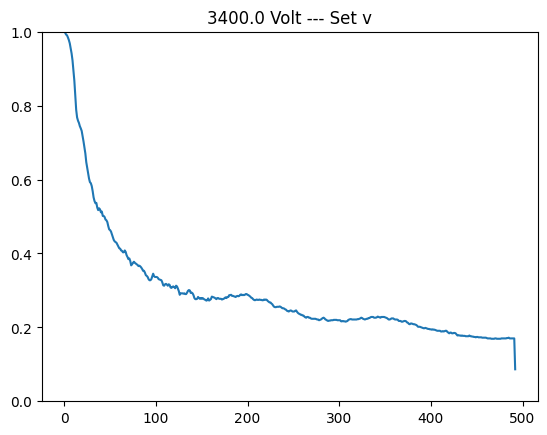

3600.0
c1
3600.0
c2
3750.0
c2
3800.0
v


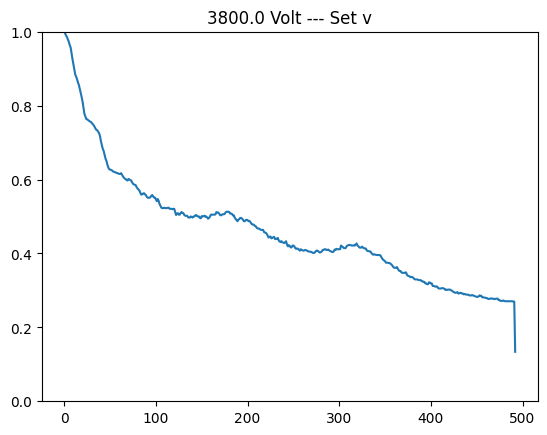

3900.0
c1
4000.0
c2
4050.0
c1
4100.0
v


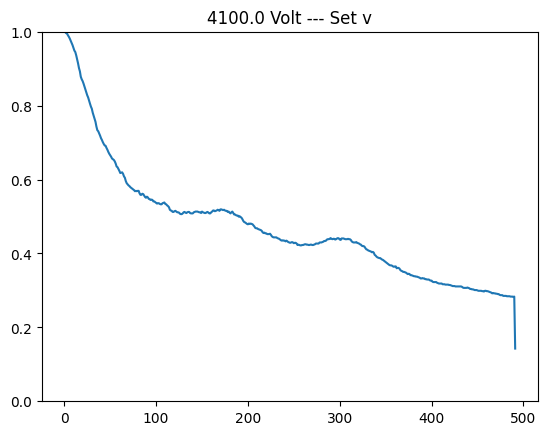

4200.0
c2
4350.0
c1
4350.0
v


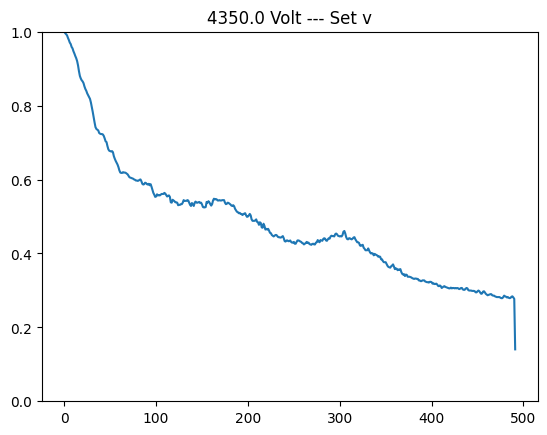

4500.0
c1
4500.0
v


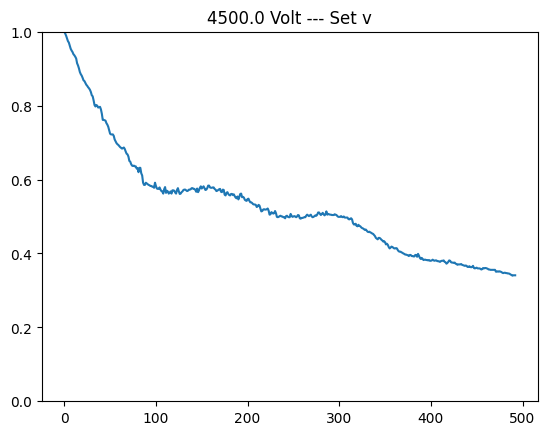

4550.0
c2


In [30]:
#CARICO TUTTI I RISULTATI IN UN DIZIONARIO DI DIZIONARI

risultati={}

for nome_file in os.listdir(percorso):
    risultati[nome_file]={}

    x, y, v, s, c, M, RC, CC = analisi(nome_file)
    
    risultati[nome_file]['R_Mesh']=x
    risultati[nome_file]['Fold']=y
    risultati[nome_file]['Voltaggio']=v
    risultati[nome_file]['Set']=s
    risultati[nome_file]['Pixel_in_mm']=c

    risultati[nome_file]['Matrice']=M
    risultati[nome_file]['Riga_Centro']=RC
    risultati[nome_file]['Colonna_Centro']=CC

    if s=='v':
        plt.title(str(v)+' Volt ---'+' Set '+s)
        plt.plot(x, y)
        plt.ylim(0,1)
        plt.show()

In [31]:
#funzione da gemini, concettualmente semplice ma non ho ancora masterato le maschere in PY
def taglia_dati(x, y, x_min, x_max):
    """
    Sotto-campiona gli array x e y in base a un intervallo definito su x.
    
    Parametri:
    x (np.ndarray): Array delle coordinate indipendenti (es. raggio).
    y (np.ndarray): Array delle coordinate dipendenti (es. intensità).
    x_min (float): Valore minimo dell'intervallo.
    x_max (float): Valore massimo dell'intervallo.
    
    Ritorna:
    tuple: (x_filtrato, y_filtrato) come np.ndarray.
    """
    # Creazione di una maschera booleana
    maschera = (x >= x_min) & (x <= x_max)
    
    # Applicazione della maschera a entrambi gli array
    return x[maschera], y[maschera]

# Esempio di utilizzo:
# r = np.linspace(0, 10, 100)
# i = np.exp(-r**2)
# r_tagliato, i_tagliato = taglia_dati(r, i, 2.0, 5.0)



def media_mobile_conv(y, finestra):
    """
    Calcola la media mobile utilizzando la convoluzione.
    y: array dei dati (intensità).
    finestra: numero di punti della finestra di media.
    """
    kernel = np.ones(finestra) / finestra
    # 'same' mantiene la dimensione dell'array originale
    return np.convolve(y, kernel, mode='same')

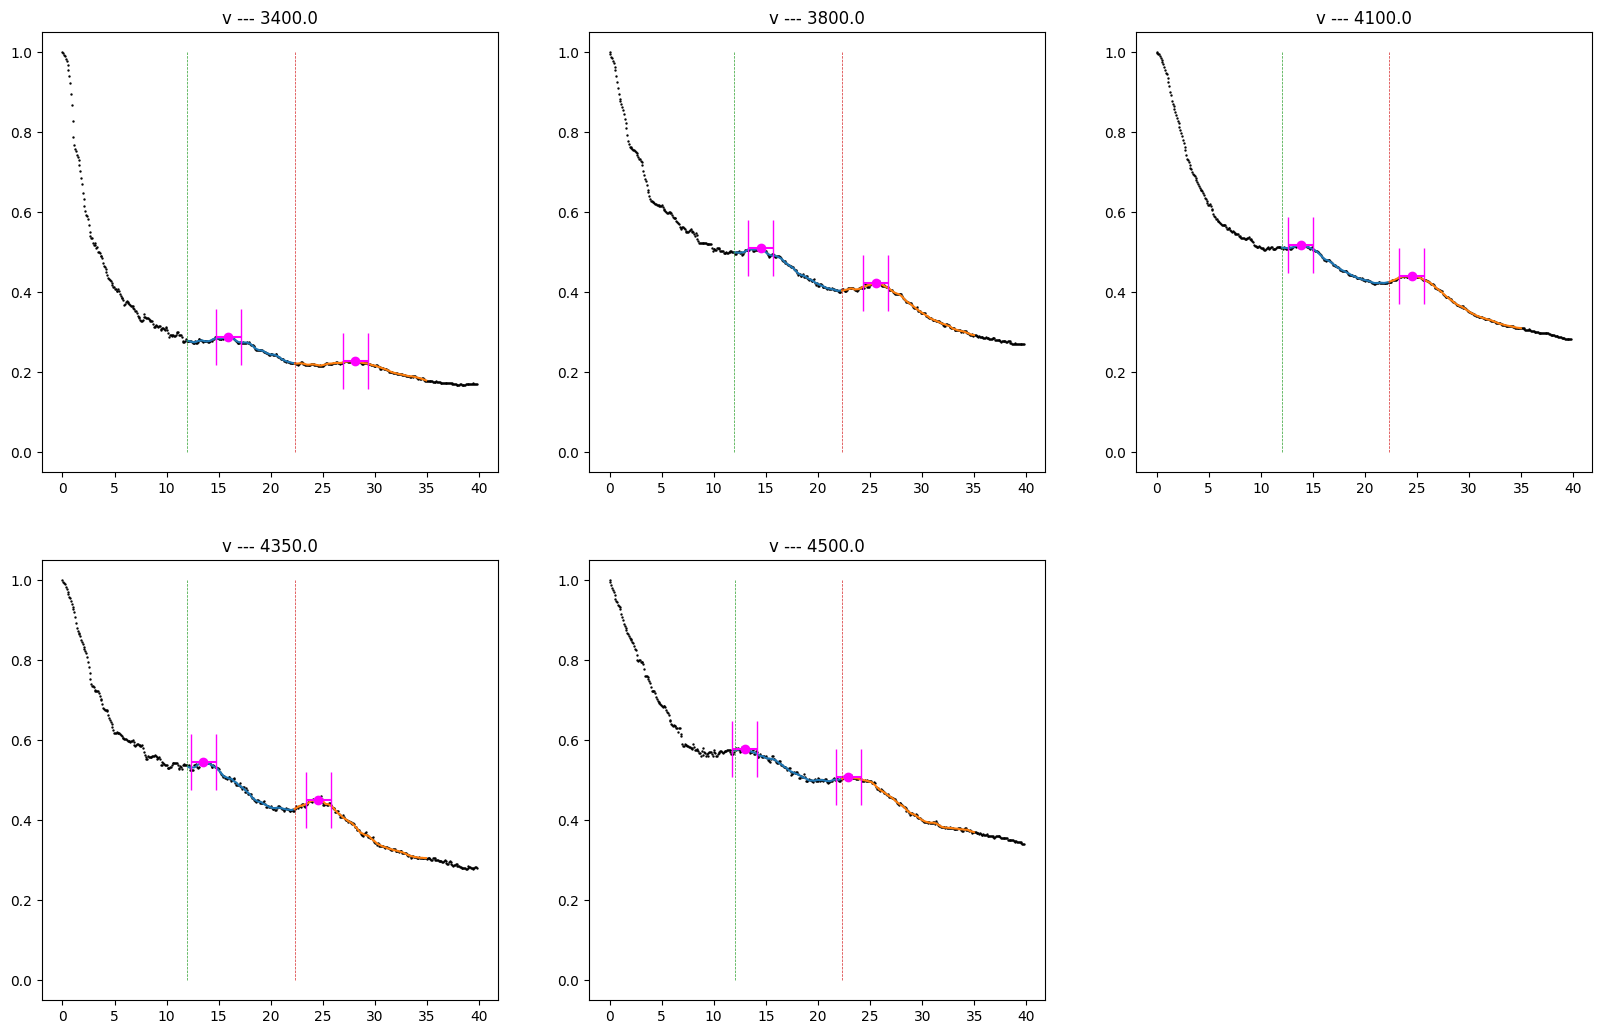

In [40]:
#LOCALIZZAZIONE GRAFICA DEI MASSIMI

#DEFINIZIONI ARBITRARIE (GRAFICHE):
i=0
retta_1=12
retta_2=22.3
err=1.2

#apertura figura
plt.figure(figsize=(20,40), dpi=100)

#ciclo for su tutti i dati
for file in risultati:    
        if risultati[file]['Set']=='v':
                #trimming dei dati e conversione delle x in mm
                x=risultati[file]['R_Mesh'][:-2]
                x=x*risultati[file]['Pixel_in_mm']
                y=risultati[file]['Fold'][:-2]
                #array di y passato sotto la media mobile
                y_med=media_mobile_conv(y, 9)

                #fette di dati tra le rette di soglia definite arbitrariamente
                cut_1_x, cut_1_y = taglia_dati(x, y_med, retta_1, retta_2)
                cut_2_x, cut_2_y = taglia_dati(x, y_med, retta_2, 35)

                #immagine
                plt.subplot(6,3,i+1)
                plt.title(risultati[file]['Set']+' --- '+str(risultati[file]['Voltaggio']))
                
                #dati originari
                plt.scatter(x, 
                        y,
                        s=.5, 
                        c='black')

                #fette di dati passate sotto media mobile
                plt.plot(cut_1_x, cut_1_y)
                plt.plot(cut_2_x, cut_2_y)   

                #indici dei massimi locali all'interno delle fette
                max_1=np.argmax(cut_1_y)
                max_2=np.argmax(cut_2_y)
                
                #inserimento dei massimi
                plt.errorbar(cut_1_x[max_1], cut_1_y[max_1],xerr=err, c='magenta', capsize=20, marker='o')    
                plt.errorbar(cut_2_x[max_2], cut_2_y[max_2],xerr=err, c='magenta', capsize=20, marker='o')
                
                #plot delle rette
                plt.plot((retta_1,retta_1), (0,1), ls='--', linewidth=0.5)
                plt.plot((retta_2,retta_2), (0,1), ls='--', linewidth=0.5)
                
                #carica i due massimi nel dizionario di dizionari
                risultati[file]['R10']=cut_1_x[max_1]
                risultati[file]['R11']=cut_2_x[max_2]

                #i++
                i+=1

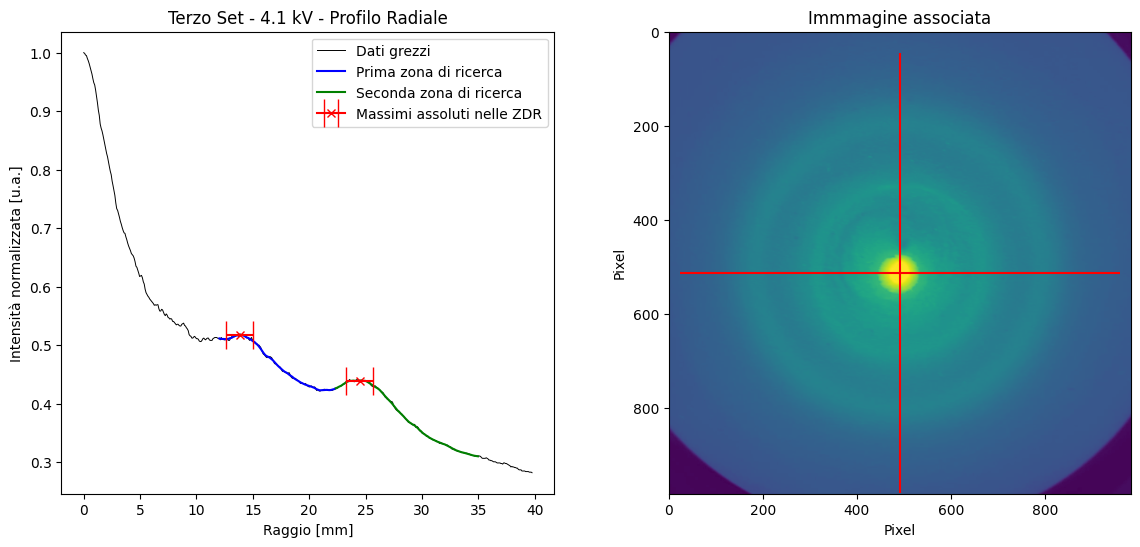

0.08133387555917039


(983, 983)

In [41]:
#PLOT ESEMPLIFICATIVO PER UN FILE
file='4100_v.jpeg'

x=risultati[file]['R_Mesh'][:-2]
x=x*risultati[file]['Pixel_in_mm']
y=risultati[file]['Fold'][:-2]

#array di y passato sotto la media mobile
y_med=media_mobile_conv(y, 9)

#fette di dati tra le rette di soglia definite arbitrariamente
cut_1_x, cut_1_y = taglia_dati(x, y_med, retta_1, retta_2)
cut_2_x, cut_2_y = taglia_dati(x, y_med, retta_2, 35)


plt.figure(figsize=(14,6))
plt.subplot(121)
plt.title('Terzo Set - 4.1 kV - Profilo Radiale')
plt.xlabel('Raggio [mm]')
plt.ylabel('Intensità normalizzata [u.a.]')

#dati originari
plt.plot(
            x, 
            y,
            linewidth=.7, 
            c='black'
        )

#fette di dati passate sotto media mobile
plt.plot(cut_1_x, cut_1_y, c='blue')
plt.plot(cut_2_x, cut_2_y, c='green')   

#indici dei massimi locali all'interno delle fette
max_1=np.argmax(cut_1_y)
max_2=np.argmax(cut_2_y)

#inserimento dei massimi
plt.errorbar(cut_1_x[max_1], cut_1_y[max_1],xerr=err, c='red', capsize=10, marker='x')    
plt.errorbar(cut_2_x[max_2], cut_2_y[max_2],xerr=err, c='red', capsize=10, marker='x')


plt.legend(('Dati grezzi', 'Prima zona di ricerca', 'Seconda zona di ricerca', 'Massimi assoluti nelle ZDR'))

plt.subplot(122)
plt.title('Immmagine associata')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
plt.scatter(risultati[file]['Riga_Centro']-0,risultati[file]['Colonna_Centro']+20, marker='+', s=100000, c='r')

plt.imshow(risultati[file]['Matrice'])


plt.show()

print(risultati[file]['Pixel_in_mm'])
risultati[file]['Matrice'].shape

In [34]:
'''import numpy as np
import matplotlib.pyplot as plt

# Parameters
cx, cy = 20, 3    # center
r = 5            # radius

theta = np.linspace(0, 2 * np.pi, 100)
x = cx + r * np.cos(theta)
y = cy + r * np.sin(theta)

plt.figure()
plt.plot(x, y)
plt.plot(cx, cy, 'ro')  # mark the center
plt.axis('equal')
plt.title(f'Circle: center=({cx},{cy}), r={r}')
plt.imshow(img)
plt.show()

'''

"import numpy as np\nimport matplotlib.pyplot as plt\n\n# Parameters\ncx, cy = 20, 3    # center\nr = 5            # radius\n\ntheta = np.linspace(0, 2 * np.pi, 100)\nx = cx + r * np.cos(theta)\ny = cy + r * np.sin(theta)\n\nplt.figure()\nplt.plot(x, y)\nplt.plot(cx, cy, 'ro')  # mark the center\nplt.axis('equal')\nplt.title(f'Circle: center=({cx},{cy}), r={r}')\nplt.imshow(img)\nplt.show()\n\n"

In [35]:
R10=[]
for file in risultati:
    R10.append((risultati[file]['R10']))
    print((risultati[file]['R10']))

KeyError: 'R10'

In [ ]:
R11=[]
for file in risultati:
    R11.append((risultati[file]['R11']))
    print((risultati[file]['R11']))

28.451178451178453
26.952526799387442
22.833333333333332
28.1072298943948
25.602660016625105
25.318471337579616
25.923016496465042
25.578562728380025
24.476110645431685
24.320652173913043
24.410774410774412
24.48149654331029
23.978201634877387
22.832618025751074
24.582824582824582
22.730241672109734
22.88032454361055
22.71006813020439


<ErrorbarContainer object of 3 artists>

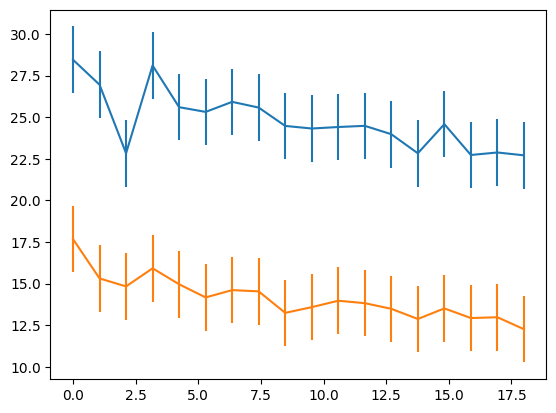

In [ ]:

plt.errorbar(np.linspace(0, 18, 18), y=R11, yerr=2)
plt.errorbar(np.linspace(0, 18, 18), y=R10, yerr=2)